In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("📤 Please upload 'arrivals_clean_filled.csv'")
print("(Click 'Choose Files' and select the file from your computer)")
print()

uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print("\n" + "="*60)
print("✅ DATA LOADED SUCCESSFULLY!")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Years: {sorted(df['date'].dt.year.unique())}")
print(f"\nStatistics:")
print(df['arrivals'].describe())

📤 Please upload 'arrivals_clean_filled.csv'
(Click 'Choose Files' and select the file from your computer)



Saving arrivals_clean_filled.csv to arrivals_clean_filled.csv

✅ DATA LOADED SUCCESSFULLY!
Shape: (96, 6)
Date range: 2018-01-01 to 2025-12-01
Years: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Statistics:
count        96.000000
mean     120476.197917
std       83585.190017
min           0.000000
25%       40970.000000
50%      120441.500000
75%      196245.250000
max      258928.000000
Name: arrivals, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle


📊 Creating Chart 1: Time Series with Events...


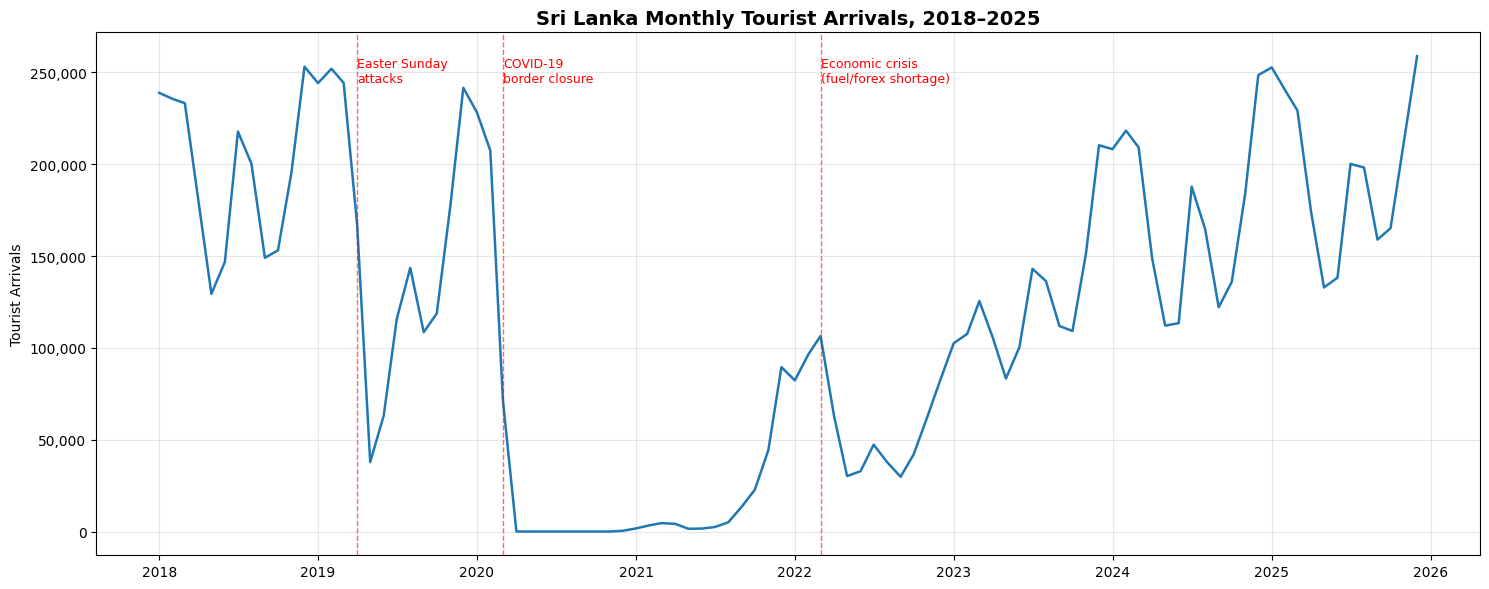

✅ Chart 1 complete


In [ ]:
# Step 2: Time series with shock events marked
# ---------------------------------------------------------------
print("\n📊 Creating Chart 1: Time Series with Events...")

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['date'], df['arrivals'], color='#1f77b4', linewidth=1.8)

events = [
    ('2019-04-01', 'Easter Sunday\nattacks'),
    ('2020-03-01', 'COVID-19\nborder closure'),
    ('2022-03-01', 'Economic crisis\n(fuel/forex shortage)'),
]
for date_str, label in events:
    event_date = pd.to_datetime(date_str)
    ax.axvline(event_date, color='red', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(event_date, ax.get_ylim()[1]*0.95, label, fontsize=9, color='red', ha='left', va='top')

ax.set_title('Sri Lanka Monthly Tourist Arrivals, 2018–2025', fontsize=14, fontweight='bold')
ax.set_ylabel('Tourist Arrivals')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print("✅ Chart 1 complete")


📊 Creating Chart 2: Seasonality Boxplot...


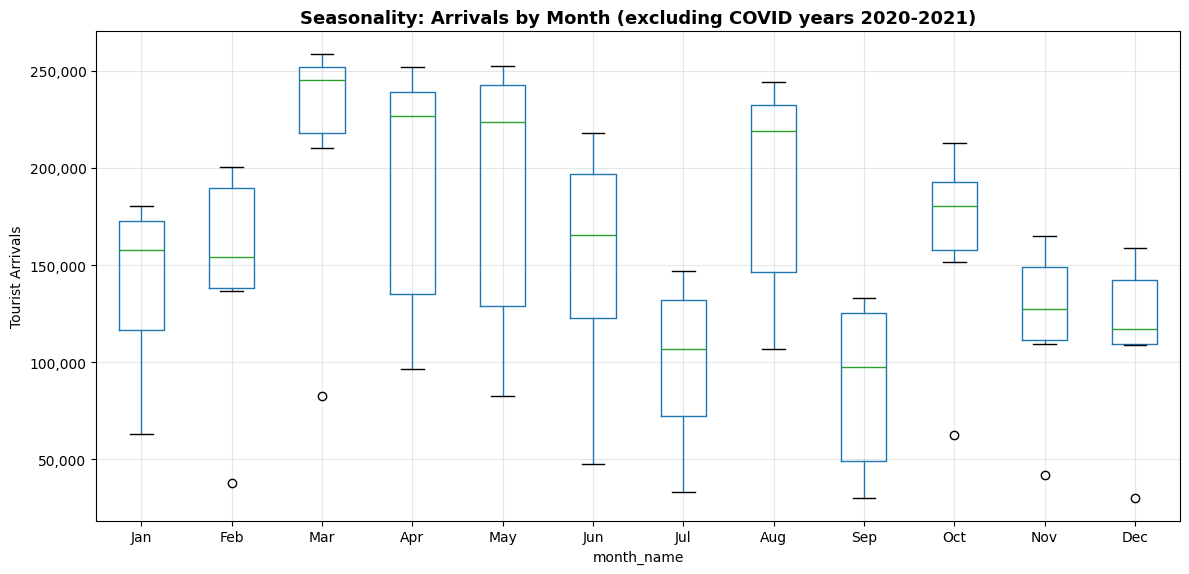

✅ Chart 2 complete


In [ ]:
# Step 3: Seasonality boxplot (excluding COVID years)
# ---------------------------------------------------------------
print("\n📊 Creating Chart 2: Seasonality Boxplot...")

df['month_name'] = df['date'].dt.strftime('%b')
df['month_num'] = df['date'].dt.month
normal_years = df[~df['date'].dt.year.isin([2020, 2021])]
order = normal_years.sort_values('month_num')['month_name'].unique()

fig, ax = plt.subplots(figsize=(12, 6))
normal_years.boxplot(column='arrivals', by='month_name', ax=ax, positions=range(len(order)))
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_title('Seasonality: Arrivals by Month (excluding COVID years 2020-2021)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tourist Arrivals')
plt.suptitle('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Chart 2 complete")


📊 Creating Chart 3: Year-over-Year Comparison...


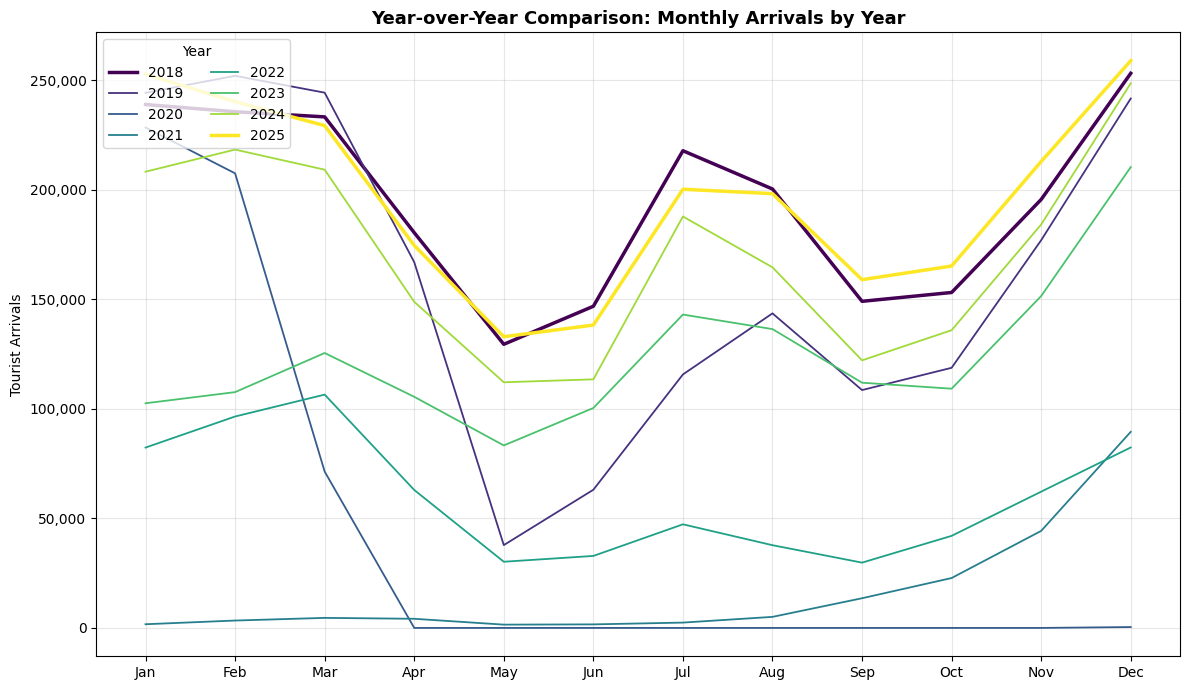

✅ Chart 3 complete


In [ ]:
# Step 4: Year-over-year overlay
# ---------------------------------------------------------------
print("\n📊 Creating Chart 3: Year-over-Year Comparison...")

df['year'] = df['date'].dt.year
years = sorted(df['year'].unique())
colors = plt.cm.viridis([i / (len(years)-1) for i in range(len(years))])

fig, ax = plt.subplots(figsize=(12, 7))
for year, color in zip(years, colors):
    year_data = df[df['year'] == year].sort_values('month_num')
    linewidth = 2.5 if year in (2018, 2025) else 1.3
    ax.plot(year_data['month_num'], year_data['arrivals'], label=str(year), color=color, linewidth=linewidth)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Year-over-Year Comparison: Monthly Arrivals by Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Tourist Arrivals')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Year', loc='upper left', ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Chart 3 complete")


📊 Creating Chart 4: Yearly Totals...


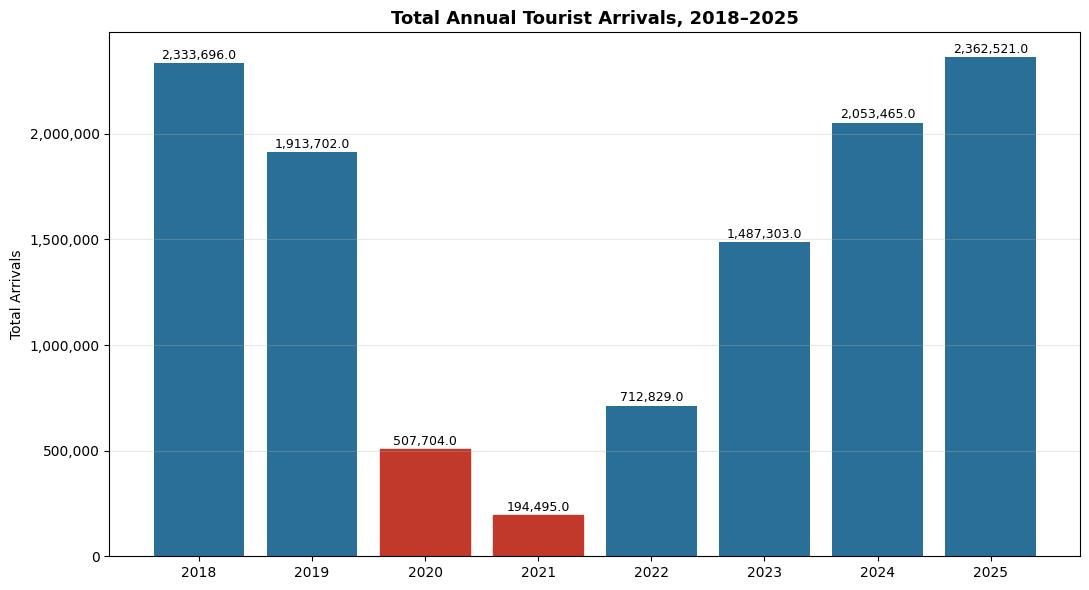

✅ Chart 4 complete

📊 Yearly totals:
   2018: 2,333,696
   2019: 1,913,702
   2020: 507,704
   2021: 194,495
   2022: 712,829
   2023: 1,487,303
   2024: 2,053,465
   2025: 2,362,521

📈 Year-over-year % change:
   2019: -18.0%
   2020: -73.5%
   2021: -61.7%
   2022: +266.5%
   2023: +108.6%
   2024: +38.1%
   2025: +15.1%


In [ ]:
# Step 5: Yearly totals bar chart
# ---------------------------------------------------------------
print("\n📊 Creating Chart 4: Yearly Totals...")

yearly = df.groupby('year')['arrivals'].sum()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(yearly.index.astype(str), yearly.values, color='#2a6f97')
for bar, year in zip(bars, yearly.index):
    if year in (2020, 2021):
        bar.set_color('#c0392b')
for bar, value in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 20000, f'{value:,}', ha='center', fontsize=9)

ax.set_title('Total Annual Tourist Arrivals, 2018–2025', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Arrivals')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("✅ Chart 4 complete")

print("\n📊 Yearly totals:")
for year, total in yearly.items():
    print(f"   {year}: {total:,.0f}")

print("\n📈 Year-over-year % change:")
pct_change = yearly.pct_change().mul(100).round(1)
for year, pct in pct_change.items():
    if not pd.isna(pct):
        print(f"   {year}: {pct:+.1f}%")


📊 Creating Chart 5: Rolling Trend...


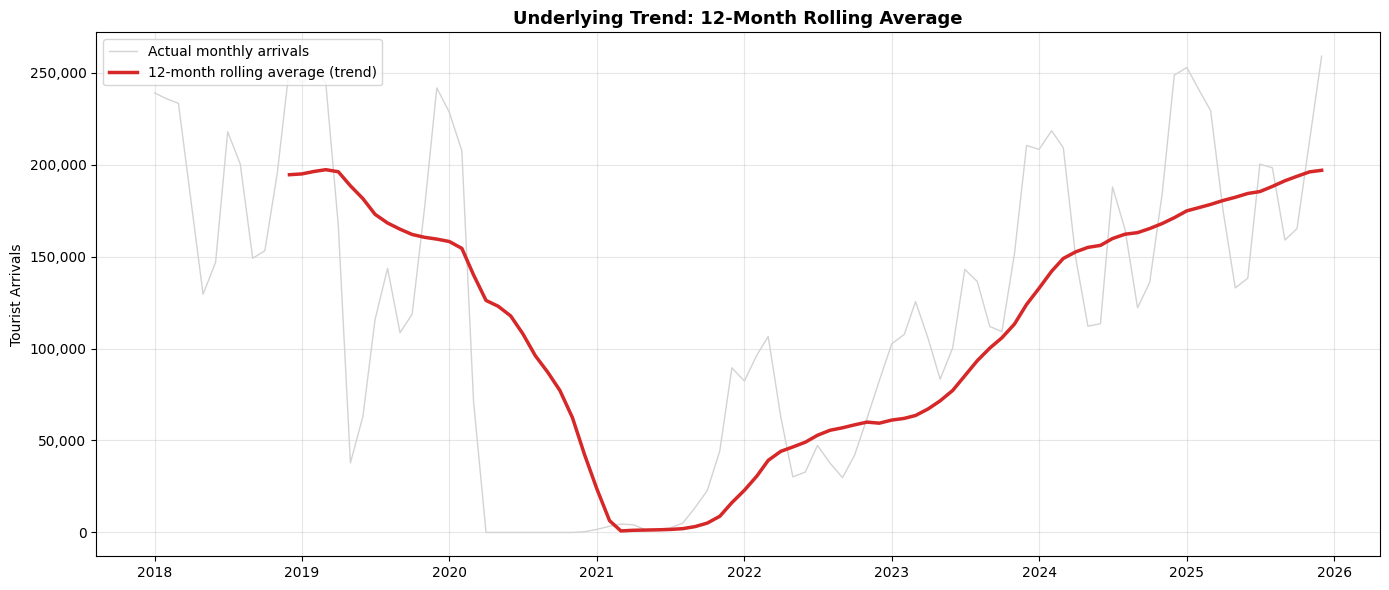

✅ Chart 5 complete


In [ ]:
# Step 6: 12-month rolling average trend
# ---------------------------------------------------------------
print("\n📊 Creating Chart 5: Rolling Trend...")

df['rolling_12m'] = df['arrivals'].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['date'], df['arrivals'], color='lightgray', linewidth=1, label='Actual monthly arrivals')
ax.plot(df['date'], df['rolling_12m'], color='#d62828', linewidth=2.5, label='12-month rolling average (trend)')
ax.set_title('Underlying Trend: 12-Month Rolling Average', fontsize=13, fontweight='bold')
ax.set_ylabel('Tourist Arrivals')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Chart 5 complete")

In [ ]:
# Summary
# ---------------------------------------------------------------
print("\n" + "="*70)
print("EDA SUMMARY")
print("="*70)

print(f"""
🏆 Best Year: {yearly.idxmax()} ({yearly.max():,.0f} arrivals)
📉 Worst Year: {yearly.idxmin()} ({yearly.min():,.0f} arrivals)
📈 Total Arrivals (8 years): {yearly.sum():,.0f}
📊 Average Monthly: {df['arrivals'].mean():,.0f}

💡 KEY INSIGHTS:
   • 2025 is the BEST year on record ({yearly[2025]:,.0f} arrivals)
   • COVID-19 caused an 73.5% drop in 2020
   • Tourism has fully recovered and exceeded pre-pandemic levels
   • December is the peak month (seasonality is strong)
   • May is the low season (monsoon period)
""")

print("="*70)
print("✅ EDA COMPLETE!")
print("="*70)


EDA SUMMARY

🏆 Best Year: 2025 (2,362,521 arrivals)
📉 Worst Year: 2021 (194,495 arrivals)
📈 Total Arrivals (8 years): 11,565,715
📊 Average Monthly: 120,476

💡 KEY INSIGHTS:
   • 2025 is the BEST year on record (2,362,521 arrivals)
   • COVID-19 caused an 73.5% drop in 2020
   • Tourism has fully recovered and exceeded pre-pandemic levels
   • December is the peak month (seasonality is strong)
   • May is the low season (monsoon period)

✅ EDA COMPLETE!
